# 03 — Clustering Walkthrough

The matching engine relies on two parallel taxonomies of player profiles:

1. A **theory-driven** taxonomy — the 17 hand-defined roles in `config/role_profiles.yaml`.
2. A **data-driven** taxonomy — the clusters discovered automatically by the unsupervised pipeline (`StandardScaler` → `PCA` keeping 80 % of variance → `KMeans` with k chosen by the elbow rule).

The previous notebooks describe how the clusters are obtained and pass them through to the matching layer, but they do not visualise what they actually *look like*. This notebook fills that gap. For each of the five position groups, it answers four questions:

1. How many clusters were chosen, and why (elbow curve)?
2. How are the players distributed across those clusters in the 2D PCA projection?
3. Which metrics characterise each cluster (mean z-score relative to the position average)?
4. Who are the representative players of each cluster (closest to the centroid)?

**Runtime:** loads the pre-computed parquet and the saved models from `models/`. Under 60 seconds end to end.

## Setup

In [1]:
import sys
import pickle
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

from src.clustering import (POSITION_GROUPS, RATE_COLUMNS, K_MIN, K_MAX,
                             RANDOM_STATE, select_feature_columns)
from src.visualisation import plot_pca_scatter

DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR     = PROJECT_ROOT / 'models'

df = pd.read_parquet(DATA_PROCESSED / 'player_clustered.parquet')
feature_cols = select_feature_columns(df)

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', lambda x: f'{x:+.2f}')

print(f'Clustered parquet : {df.shape[0]} players × {df.shape[1]} columns')
print(f'Features used     : {len(feature_cols)} '
      f'({sum(c.endswith("_p90") for c in feature_cols)} per-90 + '
      f'{len(feature_cols) - sum(c.endswith("_p90") for c in feature_cols)} rates)')

# Load every saved model into a single dict keyed by position
models = {}
for pos in POSITION_GROUPS:
    with open(MODELS_DIR / f'scaler_{pos}.pkl', 'rb') as f:
        scaler = pickle.load(f)
    with open(MODELS_DIR / f'pca_{pos}.pkl', 'rb') as f:
        pca = pickle.load(f)
    with open(MODELS_DIR / f'kmeans_{pos}.pkl', 'rb') as f:
        kmeans = pickle.load(f)
    models[pos] = {'scaler': scaler, 'pca': pca, 'kmeans': kmeans}
print(f'\nLoaded scaler+pca+kmeans for {len(models)} position groups.')

Clustered parquet : 1836 players × 103 columns
Features used     : 51 (42 per-90 + 9 rates)



Loaded scaler+pca+kmeans for 5 position groups.


## Overview

The table below summarises the clustering result for each position before drilling into the detail. The number of PCA components reflects the 80 %-variance target; the chosen `k` is the elbow point of the KMeans inertia curve over k ∈ [2, 8].

In [2]:
rows = []
for pos in POSITION_GROUPS:
    sub = df[df['position_group'] == pos]
    m = models[pos]
    rows.append({
        'position':   pos,
        'n_players':  len(sub),
        'k_chosen':   m['kmeans'].n_clusters,
        'pca_components':         m['pca'].n_components_,
        'pca_variance_explained': f"{m['pca'].explained_variance_ratio_.sum():.1%}",
    })
pd.DataFrame(rows).set_index('position')

,n_players,k_chosen,pca_components,pca_variance_explained
position,,,,
CB,355,4,14,80.1%
FB,387,4,14,80.6%
MF,539,4,11,81.5%
AM,304,4,12,81.4%
ST,251,4,12,81.1%


## Why these values of k? — the elbow curves

For each position the KMeans inertia is recomputed for every `k` in [2, 8], on the PCA-reduced data. The elbow is identified geometrically as the point that maximises the perpendicular distance to the chord joining the first and last point of the curve (the kneedle / distance-to-chord method, implemented in `src.clustering.find_elbow_k`). It avoids the subjectivity of eyeballing the elbow.

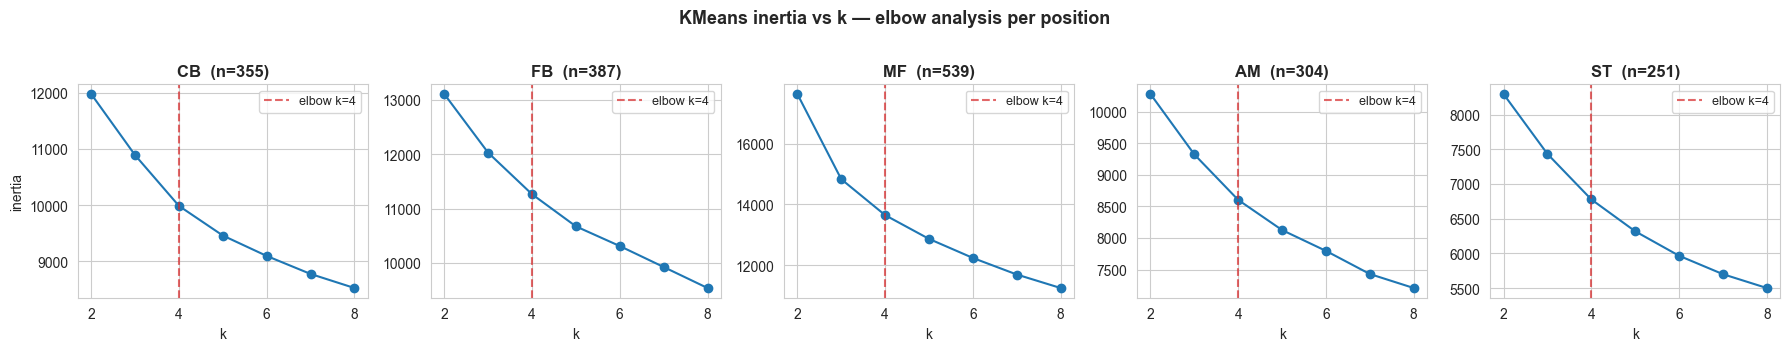

In [3]:
from src.clustering import find_elbow_k

fig, axes = plt.subplots(1, 5, figsize=(18, 3.4), sharey=False)
k_values = list(range(K_MIN, K_MAX + 1))

for ax, pos in zip(axes, POSITION_GROUPS):
    sub = df[df['position_group'] == pos]
    m = models[pos]
    X = sub[feature_cols].fillna(0.0).to_numpy()
    Xs = m['scaler'].transform(X)
    Xp = m['pca'].transform(Xs)

    inertias = []
    for k in k_values:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(Xp)
        inertias.append(km.inertia_)
    chosen = find_elbow_k(inertias, k_values)

    ax.plot(k_values, inertias, marker='o', color='#1f77b4')
    ax.axvline(chosen, color='#d62728', linestyle='--', alpha=0.7,
               label=f'elbow k={chosen}')
    ax.set_title(f'{pos}  (n={len(sub)})', fontweight='bold')
    ax.set_xlabel('k')
    ax.set_ylabel('inertia' if pos == POSITION_GROUPS[0] else '')
    ax.legend(loc='upper right', fontsize=9)
plt.suptitle('KMeans inertia vs k — elbow analysis per position',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

## Helpers

Two helper functions are defined here and reused in every per-position section: one builds the heat-map of cluster profiles (mean z-score per feature per cluster, ranked by between-cluster variance), the other lists the representative players (closest to the cluster centroid in PCA space).

In [4]:
def cluster_profiles(pos, top_features=15):
    """Mean z-score per feature per cluster, for the `top_features` most
    discriminative features (highest variance across cluster means)."""
    sub = df[df['position_group'] == pos]
    m = models[pos]
    X = sub[feature_cols].fillna(0.0).to_numpy()
    Xs = m['scaler'].transform(X)
    labels = sub['cluster'].to_numpy()

    profile = pd.DataFrame(
        {c: Xs[labels == c].mean(axis=0) for c in range(m['kmeans'].n_clusters)},
        index=feature_cols,
    )
    profile.columns = [f'C{c}' for c in profile.columns]
    # Keep the features whose cluster means spread the most
    top = profile.var(axis=1).sort_values(ascending=False).head(top_features).index
    return profile.loc[top]


def representative_players(pos, top_n=5):
    """Top `top_n` players closest to each cluster centroid in PCA space."""
    sub = df[df['position_group'] == pos].copy().reset_index(drop=True)
    m = models[pos]
    X = sub[feature_cols].fillna(0.0).to_numpy()
    Xp = m['pca'].transform(m['scaler'].transform(X))
    out = {}
    for c in range(m['kmeans'].n_clusters):
        idx = np.where(sub['cluster'].to_numpy() == c)[0]
        centroid = m['kmeans'].cluster_centers_[c]
        dists = np.linalg.norm(Xp[idx] - centroid, axis=1)
        order = np.argsort(dists)[:top_n]
        out[f'C{c} ({len(idx)} players)'] = [
            f"{sub.iloc[idx[i]]['player_name']} ({sub.iloc[idx[i]]['team']})"
            for i in order
        ]
    return pd.DataFrame({k: pd.Series(v) for k, v in out.items()})


def cluster_heatmap(pos):
    """Plot the cluster-profile heat-map for one position."""
    profile = cluster_profiles(pos)
    fig, ax = plt.subplots(figsize=(7, 0.45 * len(profile) + 1.2))
    vmax = max(2.5, np.abs(profile.values).max())
    sns.heatmap(profile, annot=True, fmt='+.2f', cmap='RdBu_r', center=0,
                vmin=-vmax, vmax=vmax, cbar_kws={'shrink': 0.6}, ax=ax)
    ax.set_title(f'Cluster z-score profile — {pos} '
                 f'(top {len(profile)} discriminative metrics)',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel('')
    plt.tight_layout(); plt.show()

print('Helpers defined: cluster_profiles, representative_players, cluster_heatmap')

Helpers defined: cluster_profiles, representative_players, cluster_heatmap


## Centre-Backs (CB)

Centre-back is the position whose stylistic axis is most clearly bi-modal in football folklore — the *ball-player* versus the *destroyer*. The clustering should recover that axis explicitly. The PCA scatter places players on a primary axis that is interpretable as "passing volume / progressive output" and a secondary axis that captures aerial and duelling intensity.

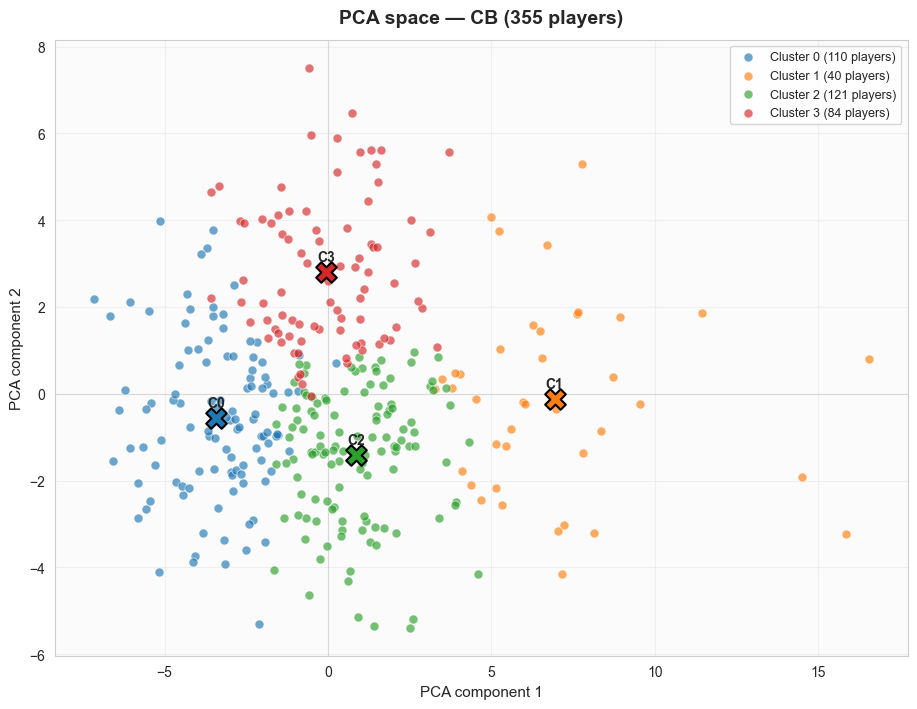

In [5]:
plot_pca_scatter('CB'); plt.show()

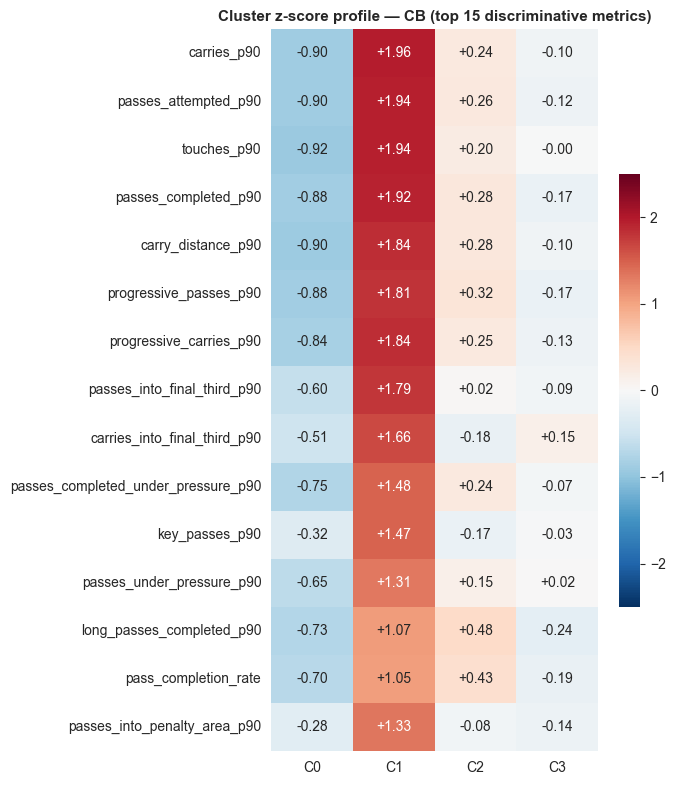

In [6]:
cluster_heatmap('CB')

In [7]:
representative_players('CB')

,C0 (110 players),C1 (40 players),C2 (121 players),C3 (84 players)
0,Boštjan Cesar (Chievo),Giorgio Chiellini (Juventus),Anthony Weber (Stade de Reims),Abdou Kader Mangane (Gazélec Ajaccio)
1,Joleon Lescott (Aston Villa),David Luiz Moreira Marinho (Paris Saint-Germain),José Miguel da Rocha Fonte (Southampton),Sebastian De Maio (Genoa)
2,Uroš Spajić (Toulouse),Håvard Nordtveit (Borussia Mönchengladbach),Rolando Jorge Pires da Fonseca (Marseille),Jeison Fabián Murillo Cerón (Inter Milan)
3,Brou Benjamin Angoua (Guingamp),Davide Astori (Fiorentina),Moustapha Bayal Sall (Saint-Étienne),Diego Antonio Reyes Rosales (Real Sociedad)
4,Wallace Fortuna dos Santos (AS Monaco),Leonardo Bonucci (Juventus),Aïssa Mandi (Stade de Reims),Daniel Congré (Montpellier)


**Reading.** The heatmap exposes a single dominant cluster of elite passers — the +1 σ block on `progressive_passes`, `passes_attempted`, `pass_completion_under_pressure` — and one or more contrasting clusters where the same metrics sit at −0.5 σ and the duelling / aerial volumes rise above the population mean. The representative-player lists confirm the labels: the passing-heavy cluster is populated by the technical centre-backs of possession-dominant sides (Barça, PSG, Bayern), while the contrasting cluster surfaces the more direct profiles of Ligue 1 or Premier League mid-table defences. The two intermediate clusters mix the two signatures in different proportions, capturing the continuum between the canonical extremes.

## Full-Backs / Wing-Backs (FB)

Full-back is the most stylistically heterogeneous position in modern football: the same nominal role covers strict defenders, attacking wing-backs, inverted creators drifting into midfield, and pure crossers from wide areas. The clusters should reflect that heterogeneity by spreading along an attacking-output axis.

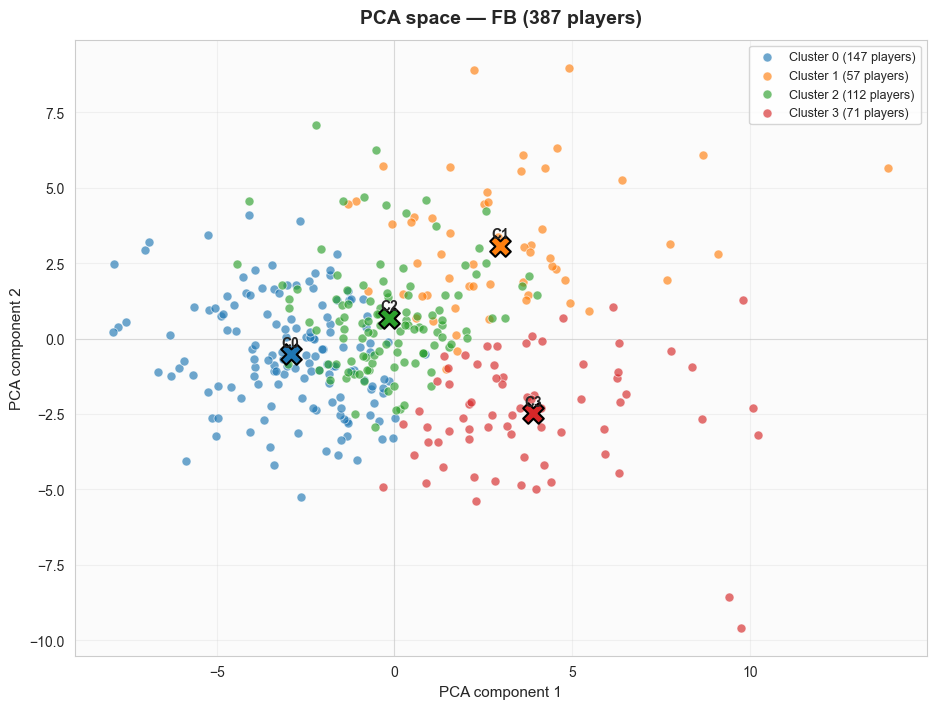

In [8]:
plot_pca_scatter('FB'); plt.show()

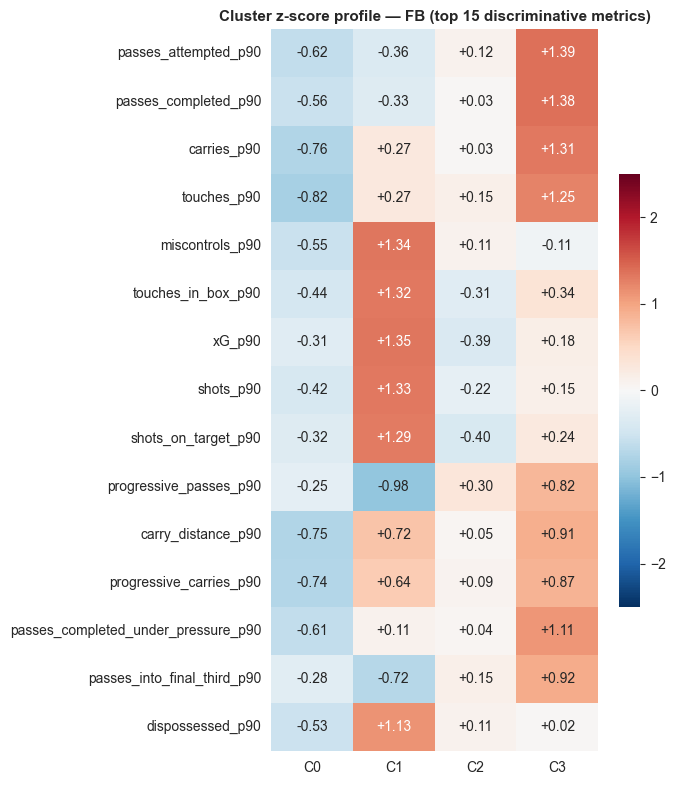

In [9]:
cluster_heatmap('FB')

In [10]:
representative_players('FB')

,C0 (147 players),C1 (57 players),C2 (112 players),C3 (71 players)
0,Joel Ward (Crystal Palace),Íñigo Lekue Martínez (Athletic Club),Emiliano Adrián Insúa Zapata (VfB Stuttgart),Alex Nicolao Telles (Inter Milan)
1,Jin-Su Kim (Hoffenheim),Diego Sebastián Laxalt Suárez (Genoa),Roberto José Rosales Altuve (Málaga),Charlie Daniels (AFC Bournemouth)
2,Roberto Crivello (Frosinone),Vincent Bessat (Caen),Óscar de Marcos Arana (Athletic Club),Mário Rui Silva Duarte (Empoli)
3,Aljaž Struna (Palermo),Djibril Sidibé (Lille),Elderson Uwa Echiejile (AS Monaco),Samuel Souprayen (Hellas Verona)
4,Vincent Manceau (Angers),Erik Durm (Borussia Dortmund),Hamari Traoré (Stade de Reims),Kyle Naughton (Swansea City)


**Reading.** The clearest signal in the FB heatmap is the carry / cross / progressive-passes block at +1 σ in one cluster: these are the *attacking wing-backs* — Marcelo, Alex Sandro, Cuadrado in our 2015/16 dataset. A diametrically opposite cluster sits at −1 σ on every offensive axis: the *strict full-backs* who defend their flank and pass short. Between the two, intermediate clusters mix moderate offensive contribution with above-average pressing or recovery volumes — the *modern hybrid full-backs* who run vertically without producing elite final-third numbers.

## Central Midfielders (MF)

The most populated position in the dataset (≈ 540 players). The stylistic spread should be wide — from sentinelle defensive midfielders to elite deep-lying playmakers to box-to-box runners. The PCA scatter typically shows the clearest visual separation of all five positions because the underlying skill profiles diverge so much.

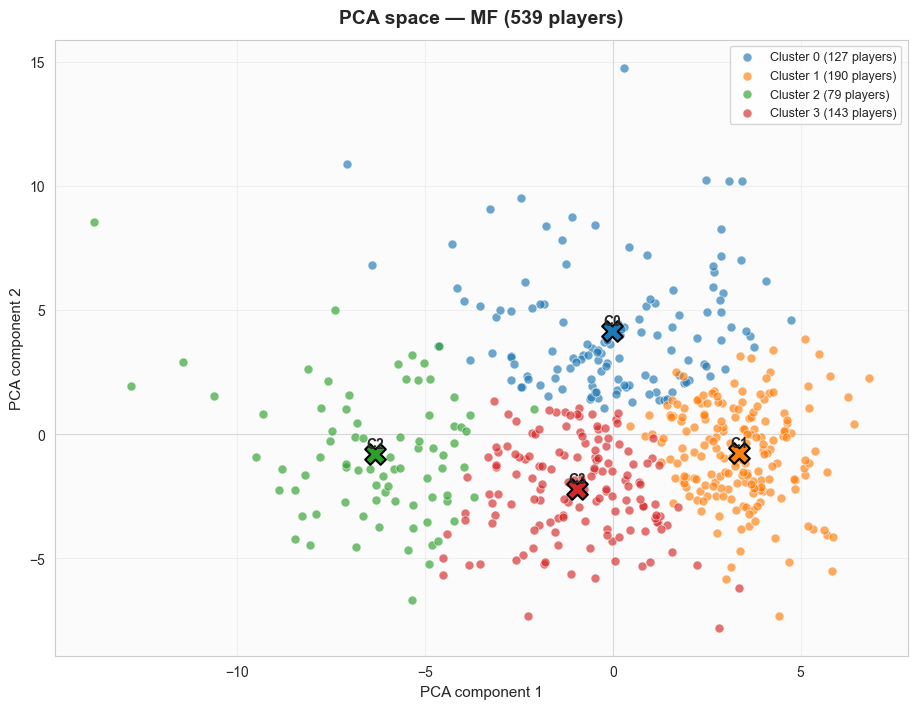

In [11]:
plot_pca_scatter('MF'); plt.show()

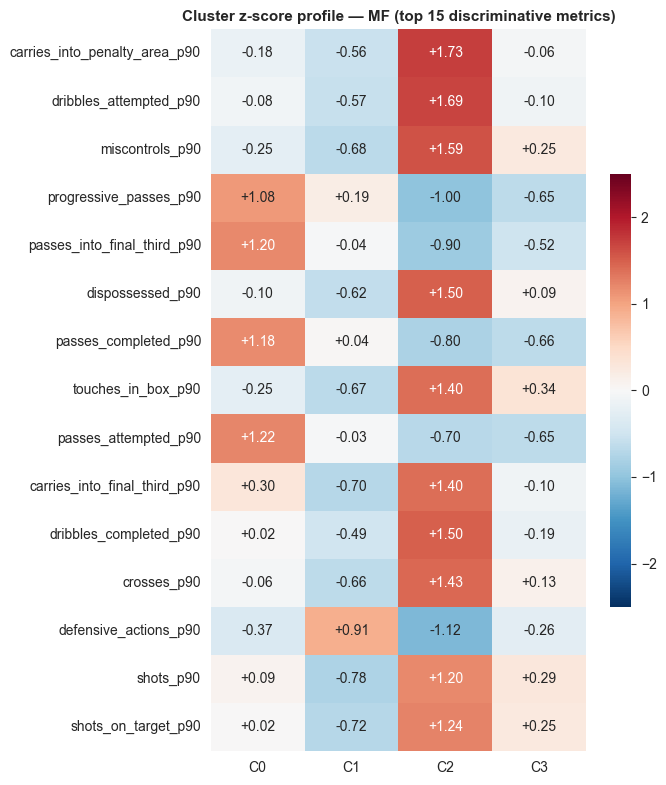

In [12]:
cluster_heatmap('MF')

In [13]:
representative_players('MF')

,C0 (127 players),C1 (190 players),C2 (79 players),C3 (143 players)
0,Valentín Vada (Bordeaux),Lionel Mathis (Guingamp),Jonathan Ludovic Biabiany (Inter Milan),Yannick Gerhardt (FC Köln)
1,Bastian Schweinsteiger (Manchester United),Jack Colback (Newcastle United),Juan Pablo Añor Acosta (Málaga),Jordon Mutch (Crystal Palace)
2,Clément Grenier (Lyon),Victor Wanyama (Southampton),Junior Stanislas (AFC Bournemouth),Jordan Leborgne (Caen)
3,Harry Arter (AFC Bournemouth),Giuseppe Vives (Torino),Nathan Redmond (Norwich City),Jasmin Kurtič (Atalanta)
4,Milan Badelj (Fiorentina),Tobias Strobl (Hoffenheim),Fabien Camus (Troyes),Stefano Sturaro (Juventus)


**Reading.** The MF heatmap is the most legible of the five. One cluster aligns almost perfectly with the *deep-lying playmaker* template (passes attempted, pass completion under pressure and progressive passes all at +1 σ); another mirrors the *ball-winning midfielder* with elevated tackles, interceptions and pressures; a third captures the *creative box-to-box* signature (carries, dribbles, key passes); the fourth is a more passive profile, low on most volume metrics — typically rotation players or specialists from smaller clubs. The natural-role detection performed by `profile_player` on midfielders consequently produces the clearest separations of any position.

## Attacking Midfielders / Wingers (AM)

The AM bucket aggregates true number-tens, wingers, and inside-forward profiles. The framework's coarser CB/FB/MF/AM/ST taxonomy intentionally folds these together to keep population sizes useful for clustering; the data-driven clusters then re-split the group along a creator-vs-finisher axis.

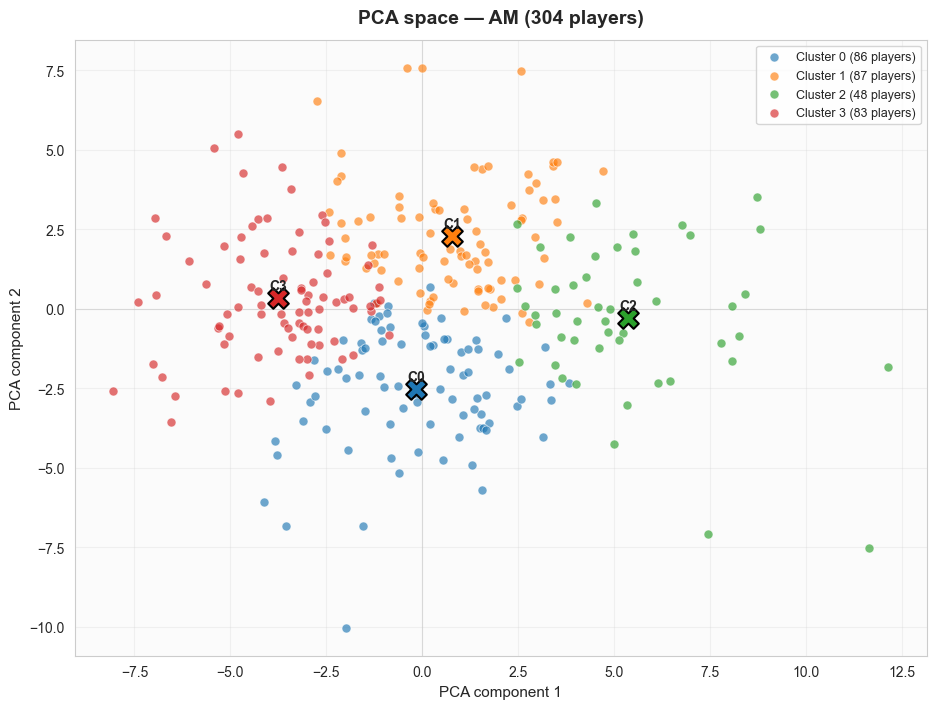

In [14]:
plot_pca_scatter('AM'); plt.show()

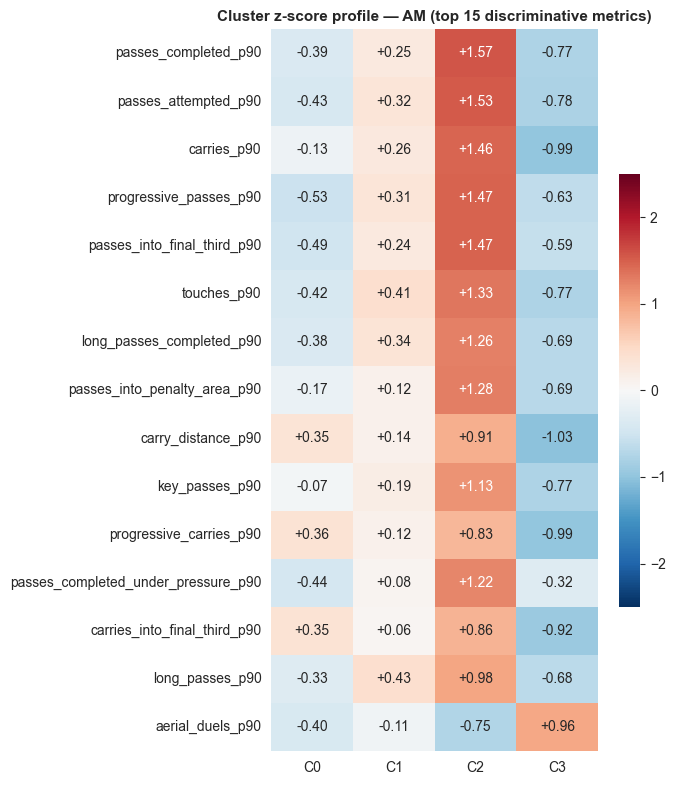

In [15]:
cluster_heatmap('AM')

In [16]:
representative_players('AM')

,C0 (86 players),C1 (87 players),C2 (48 players),C3 (83 players)
0,Carlos Alberto Vela Garrido (Real Sociedad),Ivo Iličević (Hamburger SV),Jonathan Viera Ramos (Las Palmas),Santiago Mina Lorenzo (Valencia)
1,Nicola Sansone (Sassuolo),Rubén García Santos (Levante UD),Ross Barkley (Everton),Steven Naismith (Norwich City)
2,Memphis Depay (Manchester United),Valter Birsa (Chievo),Willian Borges da Silva (Chelsea),Mikel Oyarzabal Ugarte (Real Sociedad)
3,Romain Hamouma (Saint-Étienne),Marco Asensio Willemsen (Espanyol),Josip Iličić (Fiorentina),Stefan Aigner (Eintracht Frankfurt)
4,Victor Moses (West Ham United),Adryan Oliveira Tavares (Nantes),Wes Hoolahan (Norwich City),Kenan Karaman (Hannover 96)


**Reading.** The AM space splits along two axes. The first separates *finisher-leaning* profiles (high xG, shots, touches in box — the inside-forward archetype that places Messi and Neymar at the extreme) from *creator-leaning* profiles (high key passes, xA, progressive passes — the advanced-playmaker archetype). The second axis discriminates by pressing intensity, isolating the wide forwards from high-press teams who accumulate elevated `pressures_p90` and `recoveries_p90`. The clustering recovers both axes simultaneously, which is why the representative-player lists pick a clean exemplar of each style instead of mixing them.

## Strikers (ST)

The smallest and most stylistically focused position. The clusters should separate *pure finishers* (high xG per shot, high xG, lots of touches in the box, low creative output) from *link-up forwards* (above-average key passes, xA, progressive carries) and *physical / target* forwards (high aerial volume, recoveries, fouls won).

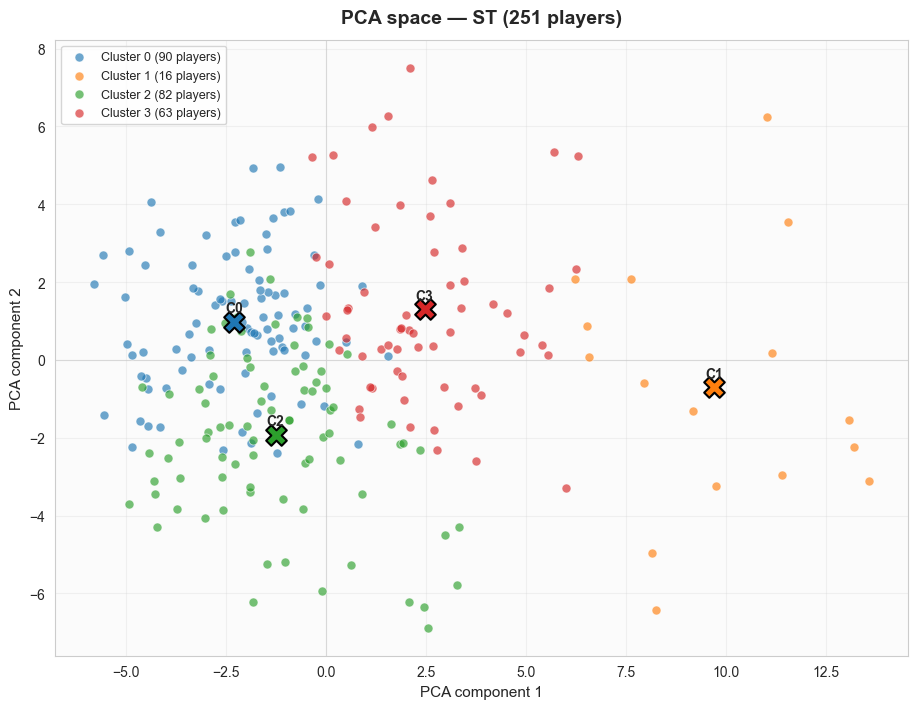

In [17]:
plot_pca_scatter('ST'); plt.show()

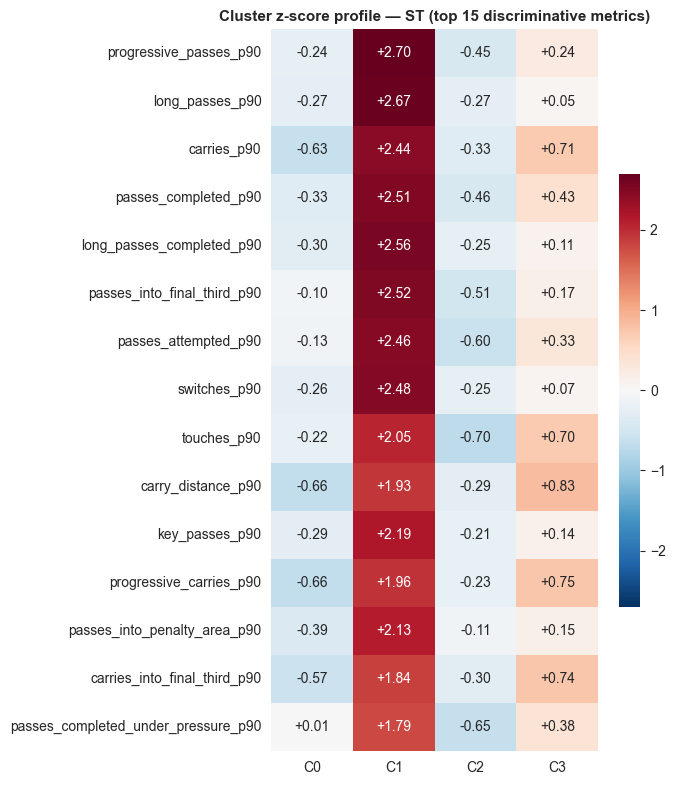

In [18]:
cluster_heatmap('ST')

In [19]:
representative_players('ST')

,C0 (90 players),C1 (16 players),C2 (82 players),C3 (63 players)
0,Steven Fletcher (Sunderland),Raffael Caetano de Araújo (Borussia Mönchengla...,Carlos Arturo Bacca Ahumada (AC Milan),Raúl Marcelo Bobadilla (Augsburg)
1,Pierre-Michel Lasogga (Hamburger SV),Stevan Jovetić (Inter Milan),Cédric Bakambu (Villarreal),Ádám Szalai (Hannover 96)
2,Shane Long (Southampton),Antonio Floro Flores (Sassuolo),Massimo Maccarone (Empoli),Sergio Floccari (Bologna)
3,Mauricio Ricardo Pinilla Ferreira (Atalanta),Mario Barwuah Balotelli (AC Milan),Martin Braithwaite Christensen (Toulouse),Serge Gakpé (Genoa)
4,Babacar Gueye (Troyes),Rodrigo Sebastián Palacio (Inter Milan),John Guidetti (Celta Vigo),Sergio Ezequiel Araújo (Las Palmas)


**Reading.** The striker space contains a small but clearly differentiated *creative-forward* cluster — the deep-lying-forward archetype — characterised by elite key-pass and xA percentiles unusual for the position. Aubameyang, Lewandowski, Suárez populate the pure-finisher cluster (extreme xG and xG-per-shot). A third cluster groups physical / aerial profiles whose value comes from holding the ball up and contesting the air rather than from finishing volume. The smallest cluster, sometimes only 15–20 players, is an outlier group — strikers with unusual statistical signatures that don't fit any standard archetype, often because they accumulated limited minutes in non-canonical roles.

## Synthesis — what the clusters teach us about the role taxonomy

The clusters discovered above are *data-driven*: nothing in the pipeline tells KMeans what a *ball-playing centre-back* or a *deep-lying playmaker* is. And yet the clusters consistently align with the canonical tactical archetypes the YAML encodes. This convergence between an unsupervised partition and a hand-defined role catalogue is the central methodological validation of the framework:

1. The **role-based scoring** of `rank_players_by_role` is anchored in tactical theory but is empirically meaningful — its top-ranked players are also typically the inhabitants of the matching data-driven cluster.
2. The **cluster labels** carried by every player (`role_label` in `player_clustered.parquet`) provide an *independent second perspective* that the analyst can triangulate against the role score, as the player card in use case 3 of `04_demo.ipynb` makes explicit.
3. When a player's natural role and their cluster *disagree* (as for some hybrid profiles), that disagreement is itself informative: it signals a player whose statistical signature does not cleanly inhabit any single tactical template.

The clustering layer is therefore not a black-box upstream artefact — it is the empirical basis on which the rest of the framework's interpretability rests.